# Exercício Prático: Classificação Botânica com Árvores de Decisão

Este notebook resolve o exercício usando o **Iris Dataset** e compara:

- uma árvore de decisão **sem restrições** (`arvore_full`)
- uma árvore de decisão com profundidade máxima **3** (`arvore_d3`)

No final, também há uma seção de **inferência manual**, onde você pode informar medidas de uma flor e obter a espécie provável.


## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


## 2. Carga e preparação dos dados

O arquivo original não possui cabeçalho, então nomeamos as colunas conforme solicitado no enunciado.


In [2]:
colunas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

try:
    df = pd.read_csv(url, names=colunas)
    fonte_dados = "UCI (arquivo original via URL)"
except Exception:
    from sklearn.datasets import load_iris

    iris = load_iris(as_frame=True)
    df = iris.frame.copy()
    df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class_encoded_temp']
    df['class'] = df['class_encoded_temp'].map(dict(enumerate(iris.target_names)))
    df = df.drop(columns=['class_encoded_temp'])
    fonte_dados = "Fallback local via sklearn.datasets.load_iris()"

# Remover linhas vazias, se existirem
df = df.dropna(how='any')

print("Fonte dos dados:", fonte_dados)
print("Dimensão do dataset:", df.shape)
display(df.head())


Fonte dos dados: UCI (arquivo original via URL)
Dimensão do dataset: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Transformação da variável alvo

A coluna `class` é convertida de texto para números usando **Label Encoding**.


In [3]:
encoder = LabelEncoder()
df['class_encoded'] = encoder.fit_transform(df['class'])

mapeamento_classes = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Mapeamento das classes:")
print(mapeamento_classes)

display(df.head())


Mapeamento das classes:
{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


,sepal_length,sepal_width,petal_length,petal_width,class,class_encoded
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


## 4. Definição de variáveis de entrada e saída

In [4]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['class_encoded']

nomes_features = X.columns.tolist()
nomes_classes = encoder.classes_.tolist()

print("Features:", nomes_features)
print("Classes:", nomes_classes)


Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 5. Modelagem

Criamos e treinamos:

- `arvore_full`: árvore sem restrições
- `arvore_d3`: árvore com profundidade máxima igual a 3


In [5]:
arvore_full = tree.DecisionTreeClassifier(random_state=42)
arvore_d3 = tree.DecisionTreeClassifier(max_depth=3, random_state=42)

arvore_full.fit(X, y)
arvore_d3.fit(X, y)

pred_full = arvore_full.predict(X)
pred_d3 = arvore_d3.predict(X)

acc_full = accuracy_score(y, pred_full)
acc_d3 = accuracy_score(y, pred_d3)

print(f"Acurácia da árvore sem restrições (treino): {acc_full:.4f}")
print(f"Acurácia da árvore com profundidade 3 (treino): {acc_d3:.4f}")


Acurácia da árvore sem restrições (treino): 1.0000
Acurácia da árvore com profundidade 3 (treino): 0.9733


## 6. Visualização da árvore `arvore_d3`

Conforme pedido no enunciado, usamos `filled=True` e passamos os nomes das classes.


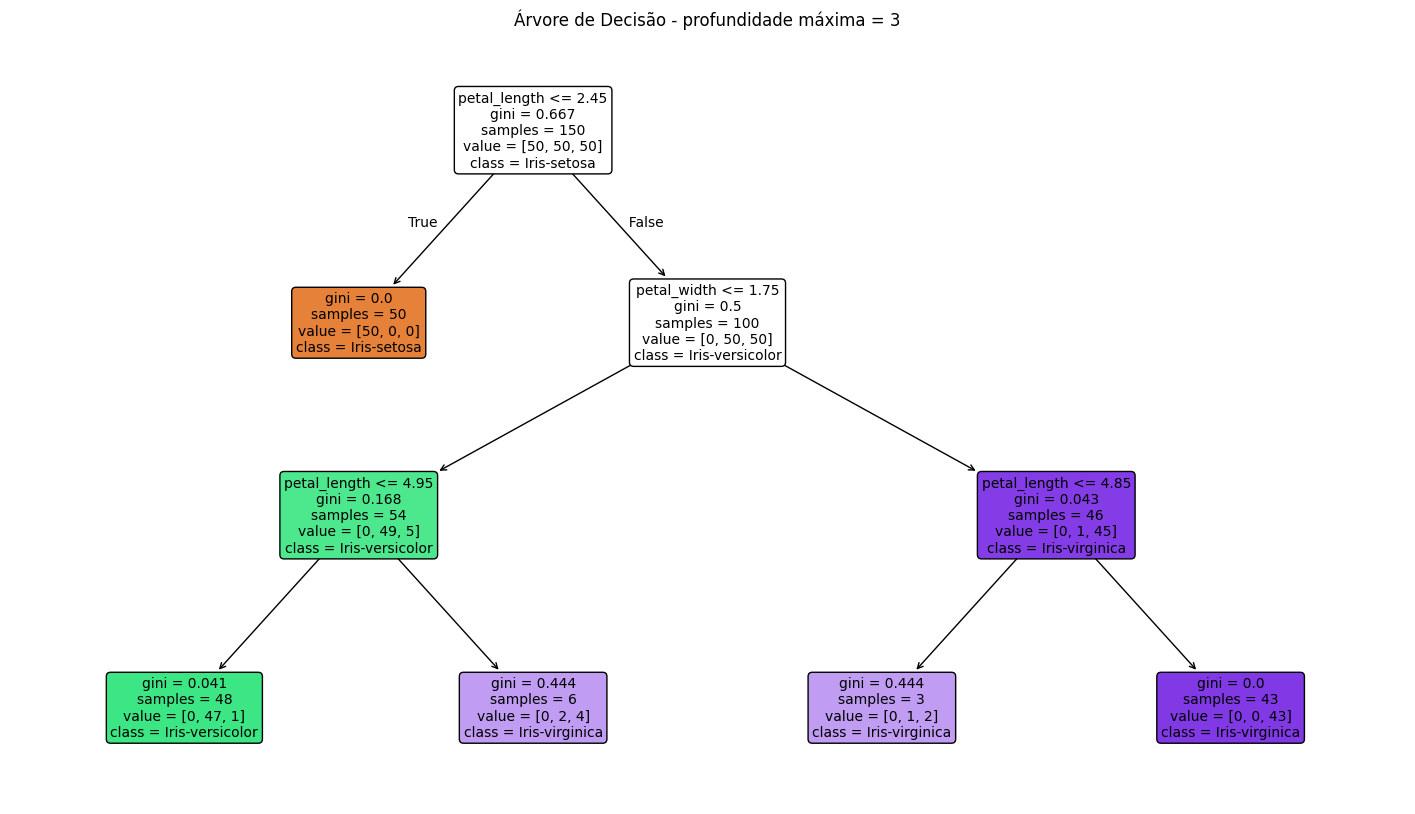

In [6]:
plt.figure(figsize=(18, 10))
tree.plot_tree(
    arvore_d3,
    feature_names=nomes_features,
    class_names=nomes_classes,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árvore de Decisão - profundidade máxima = 3")
plt.show()


## 7. Inferência manual

Altere os valores abaixo para testar novas medidas.


In [7]:
def prever_especie(sepal_length, sepal_width, petal_length, petal_width, modelo=arvore_d3):
    entrada = pd.DataFrame([{
        'sepal_length': sepal_length,
        'sepal_width': sepal_width,
        'petal_length': petal_length,
        'petal_width': petal_width
    }])

    classe_predita = modelo.predict(entrada)[0]
    especie = encoder.inverse_transform([classe_predita])[0]
    return especie

# Exemplo de inferência manual
especie_prevista = prever_especie(
    sepal_length=5.1,
    sepal_width=3.5,
    petal_length=1.4,
    petal_width=0.2,
    modelo=arvore_d3
)

print("Espécie provável:", especie_prevista)


Espécie provável: Iris-setosa


## 9. Conclusão

A árvore com profundidade limitada (`max_depth=3`) costuma ser mais interpretável e evita parte do **overfitting** da árvore totalmente livre.

Neste exercício, ela já consegue separar muito bem as espécies do conjunto Iris, especialmente a **Iris-setosa**, que costuma ser facilmente distinguida das demais.
